ml class double pendulum control problem

setup

In [1]:
''' 
# only need it once
!pip install gymnasium
!pip install "gymnasium[classic-control]"
'''

' \n# only need it once\n!pip install gymnasium\n!pip install "gymnasium[classic-control]"\n'

In [2]:
%matplotlib inline
import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
import math
import random
import torch
import torch.nn as nn

In [39]:
env = gym.make('Acrobot-v1', render_mode="rgb_array")
# Need to reset the environment to initialize it
# Resets it to a random configuration hanging down
state, _ = env.reset()
# The State
# Array is: [top_theta (in rads),         bottom_theta (in_rads),
#            top_theta_dot (in rads/sec), bottom_theta_dot (in_rads/sec)]
print("Starting in:", state)

Starting in: [0.9957267  0.09234904 0.9962305  0.08674558 0.018381   0.00996833]


In [37]:
# make the model
def new_model(width=6, depth=1):
    layers = [nn.Linear(6,width), nn.ReLU()] # start with one layer to take in my 6 observation points
    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(width,3)) # end with 3 nodes for my three actions
    # Linear regression model
    model = nn.Sequential(*layers)
    return model

# function to choose the action based on what my model says
def choose(model, state):
    # takes in a 1x3
    # grab the max and output -1,0,1
    out = model(state)
    actions = [-1,0,1]
    action = actions[torch.argmax(out)]
    return action  

def opt():
    exp = choose(target, torch.tensor(state))
    
    # Forward pass
    loss = criterion(policy(state),target(state))
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    
    

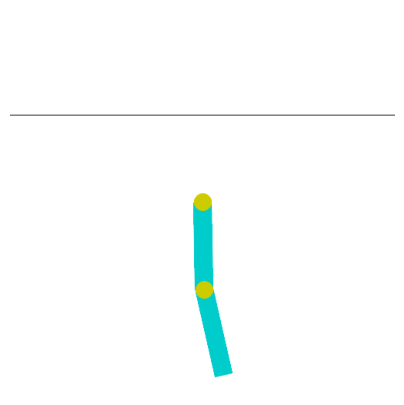

In [40]:
# one run

fig, ax = plt.subplots(figsize=(5, 5))
img = ax.imshow(env.render())
plt.axis('off')

width = 6
depth = 1

full_obs = [state]
state = torch.from_numpy(state)

policy = new_model(width, depth)
target = new_model(width, depth)
# Loss and optimizer
criterion = nn.MSELoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(policy.parameters(), lr=learning_rate)

for t in range(100): # 100 timesteps
    
    action = choose(policy,torch.tensor(state)) # can be -1 0 1 to apply torque in direction
    observation, reward, terminated, truncated, info = env.step(action) # current state, reward from state, did it win, did it run out of time
    full_obs.append(observation)

    
    state = torch.from_numpy(observation)
    opt()
    
    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)
    
    if terminated or truncated:
        break
env.close()


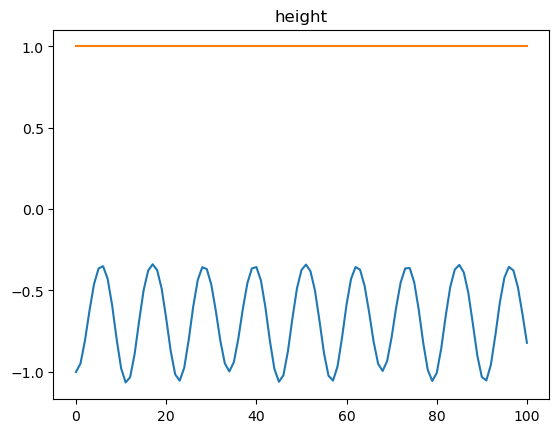

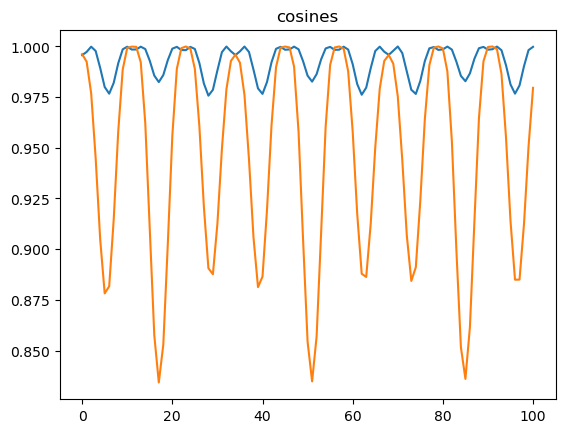

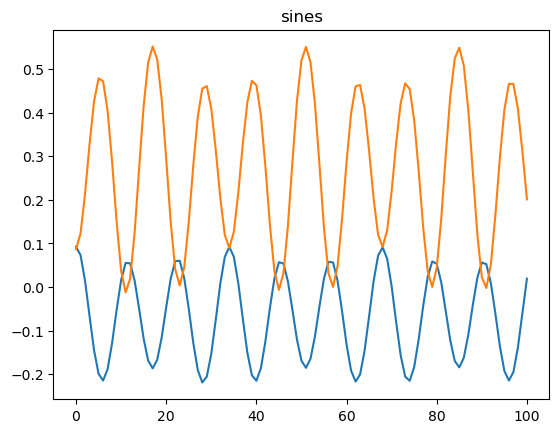

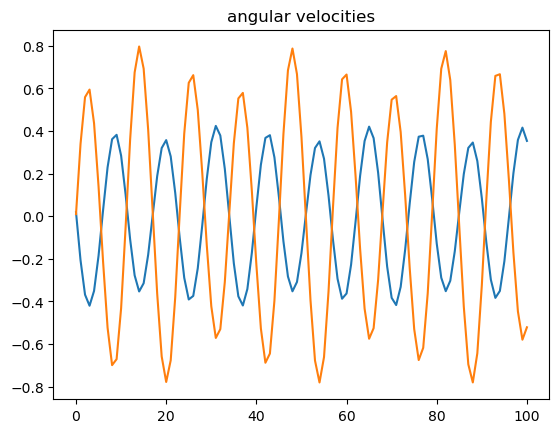

In [47]:
full_obs_np = np.array(full_obs)
# height = -(l1*cos(t1) + l2*(cos(t1)*cos(t2)-sin(t1)*sin(t2)))
# trying to get to height = 1 (not pointing straight up, just over a designated height)
l1 = 1
l2 = 1 # these are set in the thingy
height = -(l1*full_obs_np[:,0] + l2*(full_obs_np[:,0]*full_obs_np[:,1] - full_obs_np[:,2]*full_obs_np[:,3]))

# plot height
plt.plot(height,label="height")
plt.plot(np.ones(len(height)),label="target height")
plt.title("height")



# plot cosines
plt.figure()
plt.title('cosines')
plt.plot(full_obs_np[:,0],label="theta1")
plt.plot(full_obs_np[:,2],label="theta2")
# plot sines
plt.figure()
plt.title('sines')
plt.plot(full_obs_np[:,1],label="theta1")
plt.plot(full_obs_np[:,3],label="theta2")
# plot angular velocities
plt.figure()
plt.title("angular velocities")
plt.plot(full_obs_np[:,4],label="theta1")
plt.plot(full_obs_np[:,5],label="theta2")

he wants to see a plot of state-action-reward sequences, we can just manually define some right now